<a href="https://colab.research.google.com/github/Bindhya-K/ML-Practice/blob/main/RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [6]:
X,y =make_circles(n_samples=500,factor=0.1,noise=0.3,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

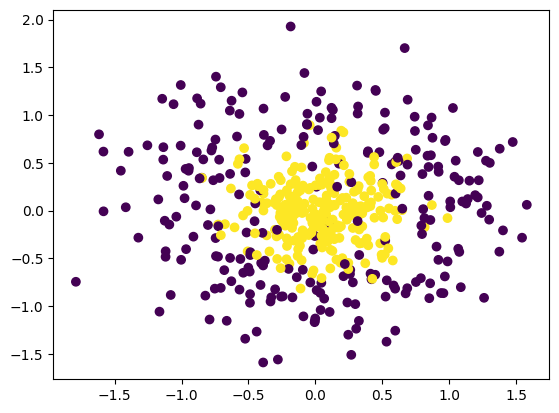

In [7]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [9]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)


DecisionTreeClassifier(random_state=42)

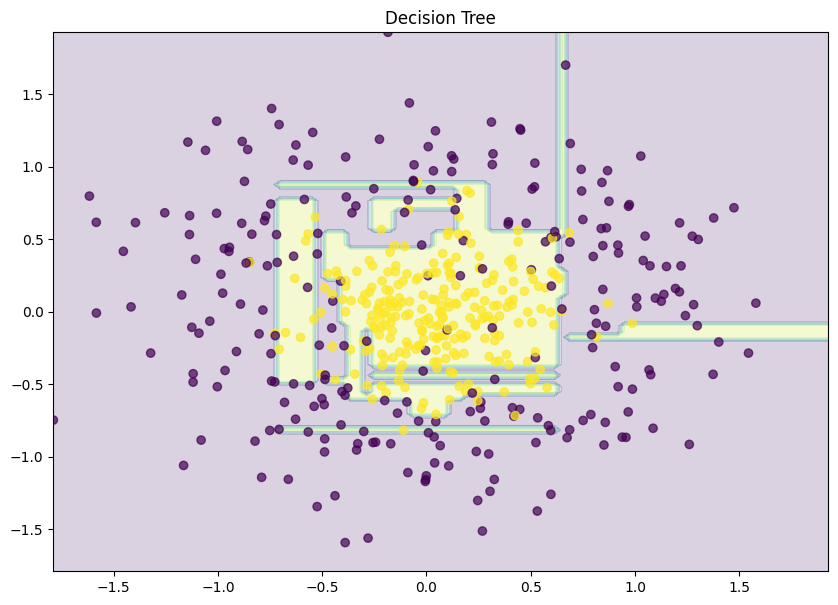

In [17]:
plt.figure(figsize=(10,7))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_pred = dt.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_pred = y_pred.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_pred,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title("Decision Tree")
plt.show()


fully grown DT. its overfitting(LB HV)
gives good result in training , but bad result on test dataset

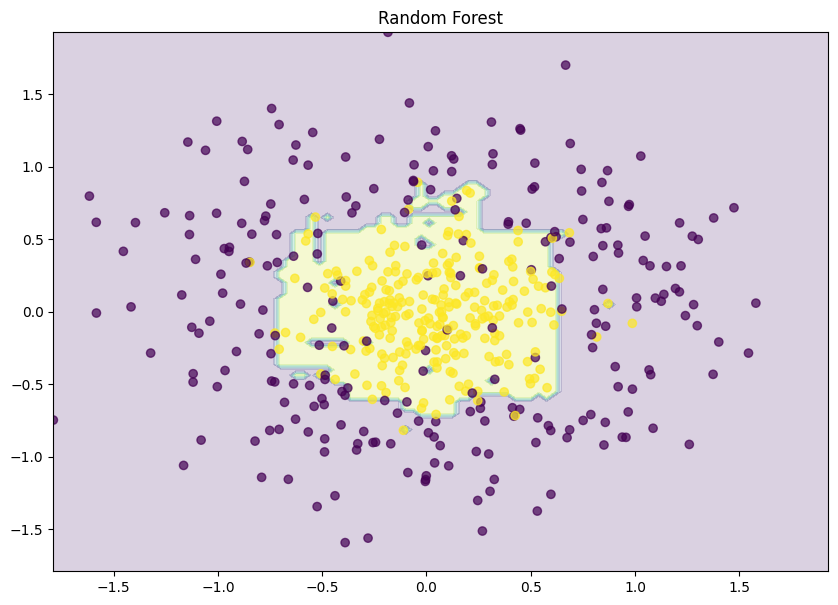

In [19]:
rf = RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(X_train,y_train)
plt.figure(figsize=(10,7))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_pred = rf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_pred = y_pred.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_pred,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title("Random Forest")
plt.show()


graph shows LB and LV. some bias may get increase

## GridsearchCV

In [22]:
from sklearn.model_selection import GridSearchCV
estimators = [20,60,100,120]
max_features = [0.2,0.6,1.0]
max_depth=[2,8,None]
max_samples = [0.5,0.75,1.0]
# 4*3*3*3 =108 random forests are training
parameters = {
    'n_estimators':estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'max_samples':max_samples
}
rf = RandomForestClassifier()
rf_grid = GridSearchCV(estimator=rf,param_grid=parameters,cv=5,
                       verbose=2,n_jobs=-1)
#cv=5 each RF is trained 5 times
# verbose=2 output diplayed

In [23]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [24]:
rf_grid.best_params_

{'max_depth': 2, 'max_features': 0.2, 'max_samples': 1.0, 'n_estimators': 100}

In [25]:
rf_grid.best_score_

np.float64(0.8675)

### RandomSearch Cv
IF the dataset is large, gridsearch cv becomes slow, then use randomsearch cv, it uses only randomly select parameters and trained it. not all 504 fits

In [26]:
estimators = [20,60,100,120]
max_features = [0.2,0.6,1.0]
max_depth=[2,8,None]
max_samples = [0.5,0.75,1.0]
bootstrap = [True,False]
min_samples_split = [2,5,10]
min_samples_leaf = [1,2,5]


In [30]:
param_grid = {
    'n_estimators':estimators,
    'max_features':max_features,
    'max_depth':max_depth,
    'max_samples':max_samples,
    'min_samples_split':min_samples_split,
    'min_samples_leaf':min_samples_leaf
}


In [31]:
from sklearn.model_selection import RandomizedSearchCV
rf_grid=RandomizedSearchCV(estimator=rf,
                           param_distributions=param_grid,
                           cv=5,
                           verbose=2,
                           n_jobs=-1)

In [32]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [2, 8, None],
                                        'max_features': [0.2, 0.6, 1.0],
                                        'max_samples': [0.5, 0.75, 1.0],
                                        'min_samples_leaf': [1, 2, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [20, 60, 100, 120]},
                   verbose=2)

In [33]:
rf_grid.best_params_

{'n_estimators': 20,
 'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_samples': 0.5,
 'max_features': 1.0,
 'max_depth': None}

In [34]:
rf_grid.best_score_

np.float64(0.8700000000000001)

In [3]:
df = pd.DataFrame(X,columns=['f1','f2','f3','f4','f5'])
df['target'] = y
df.head()

,f1,f2,f3,f4,f5,target
0,0.686744,0.624015,0.329970,-1.865808,1.478756,0
1,0.016601,1.273540,-2.072541,0.391390,1.230634,0
2,0.029487,1.227296,0.846696,-3.263145,2.671089,0
3,-1.935887,-0.424932,-2.305585,1.568574,1.388382,1
4,2.498097,2.263346,1.168009,-3.494515,2.186959,0
